# `SegResNet` Model Inference Test
After training a `SegResNet()` model on the **MSD** brain tumor dataset, the next step is to load the saved weights and preform ***Segmentation Inference*** on a post-treatment NIfTI volume of a *glioma* patient.  Goals of this test:
- Create a custom loader that will load the NIfTI volume files
- Collapse the *labels* into multi-channels to conform with **BraTS** standards
- Create **inference** and **validation** datasets
- Perform inference on a single post-treatment volume
- The dataset also includes a single professionally annotated segmented volume for *ground truth*
- Display some of the slices
- Calculate metrics that indicate how well the model predicted the ROIs

----
<a name='startup_tasks'></a>
## 1.0 <span style='color:blue'>|</span> Common Start Up Tasks

<a name='load_packages'></a>
### 1.1 <span style='color:blue'>|</span> Load Required Packages and Libraries

In [1]:
import os, torch, random, warnings, gc
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        # Fixes a warning from PyTorch
from monai.data import Dataset, DataLoader, decollate_batch
from monai.transforms import(
    LoadImaged, EnsureChannelFirstd, EnsureTyped, EnsureChannelFirstd,
    Orientationd, Spacingd, RandSpatialCropd, RandFlipd, Activations,
    NormalizeIntensityd, RandScaleIntensityd, RandShiftIntensityd,
    Compose, MapTransform, Invertd, Activationsd, AsDiscrete, AsDiscreted
)
from monai.networks.nets import SegResNet
from monai.inferers import SlidingWindowInferer, sliding_window_inference
from monai.utils import set_determinism
from nilearn import plotting, image
from monai.handlers.utils import from_engine
from monai.metrics import DiceMetric

# Make plots have guidelines
plt.style.use('ggplot')

# Squash Python warnings
warnings.filterwarnings('ignore')

# Enable Python's Garbage Collector
gc.collect()

2026-03-06 08:11:55.754537320 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-06 08:12:01.898291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


0

<a name='global_variables'></a>
### 1.2 <span style='color:blue'>|</span> Declare Global Variables

In [2]:
SEED = 42
ROOT_DIR = '../monai'
POST_DIR = '../post/PatientID_0015/Timepoint_1'
BEST_DIR = './weights'
OUT_DIR  = '../post/seg_out'
MAX_EPOCHS = 200
VAL_INTERVAL = 1
VAL_AMP = True
NUM_WORKERS = 4
ROI_SIZE = [128, 128, 64]
PIX_DIM = (1.0, 1.0, 1.0)
BATCH_SIZE = 4

# Ensure GPU is used by PyTorch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

<a name='random_seed'></a>
### 1.3 <span style='color:blue'>|</span> Set Random Seed and PyTorch Backend Optimizations

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
set_determinism(SEED)

# When running on CuDNN backend, it is recommended to set these two options
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.set_float32_matmul_precision('medium')

----
<a name='classes_functions'></a>
## 2.0 <span style='color:blue'>|</span> Define Classes and Functions

<a name='multichannel_class'></a>
### 2.1 <span style='color:blue'>|</span> Define a New Transform to Convert Brain Tumor Labels
Convert the multi-classes labels into multi-labels segmentation in One-Hot format

In [4]:
class ConvertToMultiChannel(MapTransform):
    '''
    Convert labels to multi-channels based on BraTS classes:
        label 1 -> Peritumoral edema (ED)
        label 2 -> GD-enhancing tumor (ET)
        label 3 -> Necrotic and non-enhancing tumor core (NEC/NTC)

        Possible classes are TC (Tumor Core), WT (Whole Tumor), and ET (Enhancing Tumor)
    '''
    
    def __call__(self, data):
        data_dict = dict(data)
        for key in self.keys:
            result = []

            # Collapse label 2 and 3 to construct TC
            result.append(torch.logical_or(data_dict[key] == 2, data_dict[key] ==3))

            # Merge labels 1, 2, and 3 to constuct WT
            result.append(torch.logical_or(torch.logical_or(data_dict[key] == 2, 
                           data_dict[key] == 3), data_dict[key] == 1))

            # Label 2 is ET
            result.append(data_dict[key] == 2)
            data_dict[key] = torch.stack(result, axis=0).float()
        return data_dict

<a name='build_file_list'></a>
### 2.2 <span style='color:blue'>|</span> Build a List of Files
Inference dataset will only have the modality NIfTI files (i.e. t1n, t1c, t2w, and t2f).  Validation dataset will also have the *tumorMask* NIfTI volume to be used as the *ground truth*

In [5]:
def build_file_list(subject_dir: str, inference:bool = False):
    '''
    Builds a list with a single entry for one subject.
    
    Args:
        subject_dir: Path to the folder containing t1n.nii.gz, t1c.nii.gz, etc.
        inference: boolean that indicates if we should include labels or not
    
    Returns:
        List with one dict: {'image': [mod_paths...], 'label': label_path}
    '''
    image_paths = [
        os.path.join(subject_dir, 'PatientID_0015_Timepoint_1_brain_t1n.nii.gz'),
        os.path.join(subject_dir, 'PatientID_0015_Timepoint_1_brain_t1c.nii.gz'),
        os.path.join(subject_dir, 'PatientID_0015_Timepoint_1_brain_t2w.nii.gz'),
        os.path.join(subject_dir, 'PatientID_0015_Timepoint_1_brain_t2f.nii.gz'),
    ]
    
    # If there is no tumorMask or seg file, then comment out
    if not inference:
        label_path = os.path.join(subject_dir, 'PatientID_0015_Timepoint_1_tumorMask.nii.gz')
        return [{'image': image_paths, 'label': label_path}]
    else:
        return [{'image': image_paths}]

In [6]:
def inference(input):
    def _compute(input):
        return sliding_window_inference(
            inputs = input,
            roi_size = ROI_SIZE,
            sw_batch_size = BATCH_SIZE,
            predictor = model,
            overlap = 0.5,
        )

    if VAL_AMP:
        with torch.autocast('cuda'):
            return _compute(input)
    else:
        return _compute(input)

----
<a name='do_work'></a>
## 3.0 <span style='color:blue'>|</span> Do the Work

<a name='define_transforms'></a>
### 3.1 <span style='color:blue'>|</span> Define Transformations for Inference and Validation Datasets

In [7]:
inference_transform = Compose([
    LoadImaged(keys=['image'], image_only=True),
    EnsureChannelFirstd(keys=['image']),
    EnsureTyped(keys=['image']),
    Orientationd(keys=['image'], axcodes='RAS'),
    Spacingd(keys=['image'], pixdim=PIX_DIM, mode='bilinear'),
    NormalizeIntensityd(keys=['image'], nonzero=True, channel_wise=True)
])

val_transform = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image']),
    ConvertToMultiChannel(keys=['label']),
    Spacingd(keys=['image', 'label'],
             pixdim=PIX_DIM,
             mode=('bilinear', 'nearest')),
    NormalizeIntensityd(keys=['image'], nonzero=True, channel_wise=True)
])

post_transforms = Compose(
    [
        Invertd(
            keys='pred',
            transform=val_transform,
            orig_keys='image',
            meta_keys='pred_meta_dict',
            orig_meta_keys='image_meta_dict',
            meta_key_postfix='meta_dict',
            nearest_interp=False,
            to_tensor=True,
            device='cpu',
        ),
        Activationsd(keys='pred', sigmoid=True),
        AsDiscreted(keys='pred', threshold=0.5),
    ]
)

<a name='dataloader_and datasets'></a>
### 3.2 <span style='color:blue'>|</span> Create Datasets and Loaders

In [8]:
# Inference - No label (segmentation or mask file)
data_infer = build_file_list(subject_dir=POST_DIR, inference=True)
infer_ds = Dataset(data=data_infer, transform=inference_transform)
infer_dl = DataLoader(infer_ds, batch_size=BATCH_SIZE)

# Validation - With label (segmentation or mask file
data_val = build_file_list(subject_dir=POST_DIR, inference=False)
val_ds = Dataset(data=data_val, transform=val_transform)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

<a name='display_image'></a>
### 3.3 <span style='color:blue'>|</span> Visualize NIfTI Volume's Labels and Channels
Sanity test to ensure *datasets* are as expected

image shape: torch.Size([4, 240, 240, 155])


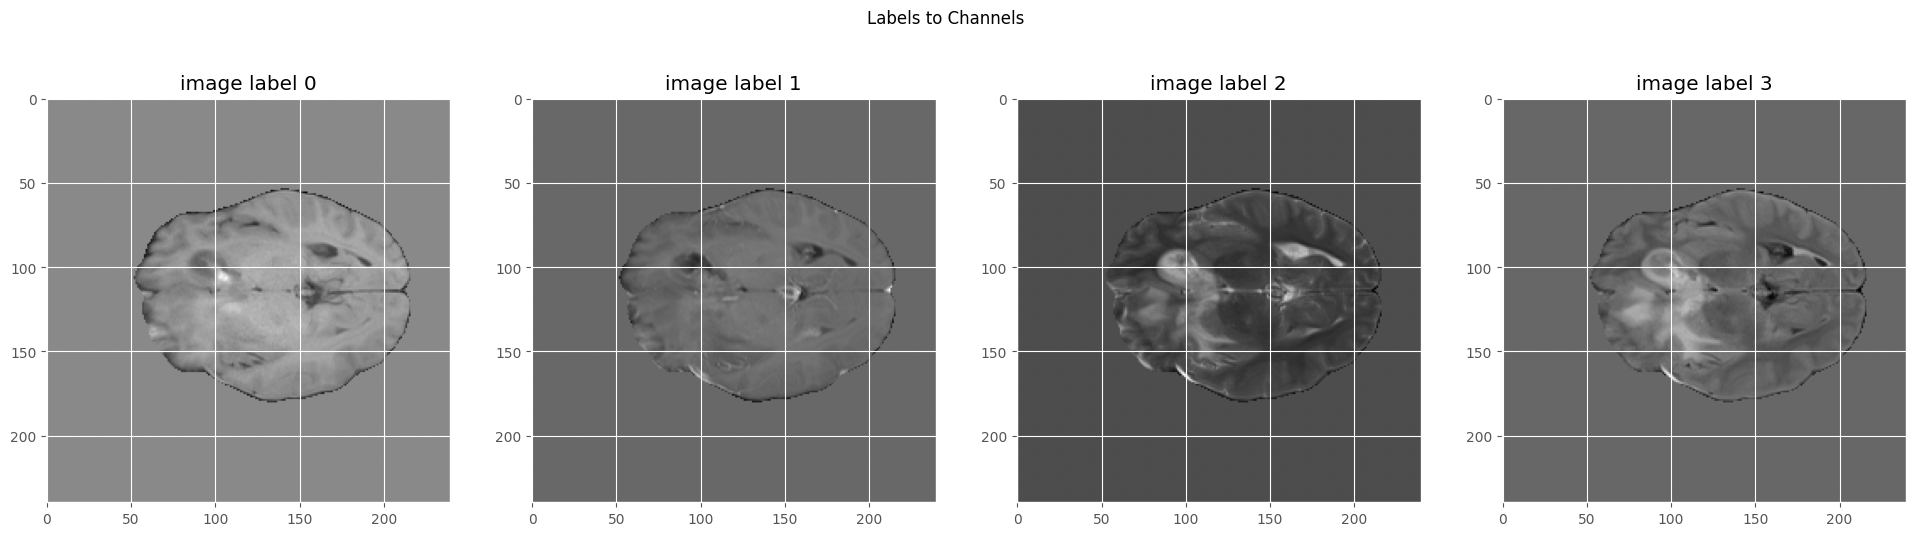

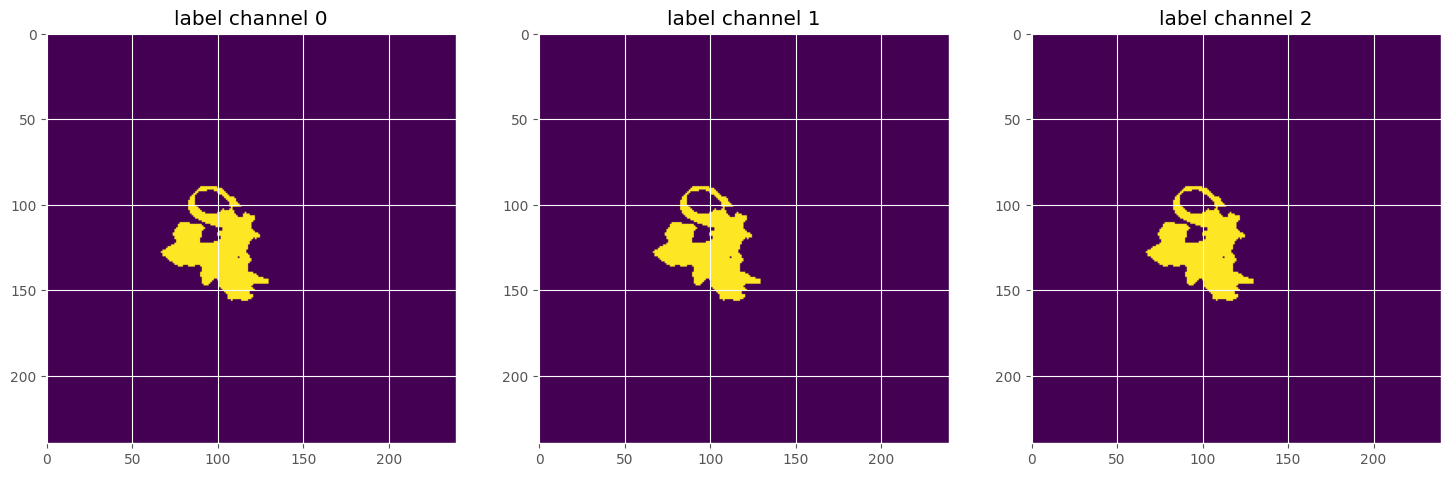

In [9]:
# There is only one image in the dataset
val_data_example = val_ds[0]
slice = 70
print(f'image shape: {val_data_example['image'].shape}')
plt.figure('image', (24, 6))
plt.suptitle('Labels to Channels')
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f'image label {i}')
    plt.imshow(val_data_example['image'][i, :, :, slice].detach().cpu(), cmap='gray')
plt.savefig('../report/figures/exp_labels.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Visualize the segmentation labels

plt.figure('label', (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'label channel {i}')
    plt.imshow(val_data_example['label'][i, :, :, slice].detach().cpu())
plt.savefig('../report/figures/exp_channels.jpg', dpi=300, bbox_inches='tight')
plt.show()

<a name='ceate_model'></a>
### 3.4 <span style='color:blue'>|</span> Define **`SegResNet()`** Model

In [10]:
model = SegResNet(
    blocks_down  = [1, 2, 2, 4],
    blocks_up    = [1, 1, 1],
    init_filters = 16,
    in_channels  = 4,
    out_channels = 3,
    dropout_prob = 0.2).to(DEVICE)

<a name='inference_segmentation'></a>
### 3.5 <span style='color:blue'>|</span> Load Model Weights, Perform Segmentation Inference
There are no labels in the *inference* dataset, only images.  Also, compute probabilities for each mask

In [11]:
model.load_state_dict(torch.load(os.path.join(BEST_DIR, '1772726471best_metric_model.pth'), 
                                 map_location=DEVICE))
model.eval()

inferer = SlidingWindowInferer(
    roi_size=ROI_SIZE,
    sw_batch_size=BATCH_SIZE,
    overlap=0.5,
    mode='gaussian',
    cache_roi_weight_map=True
)

with torch.no_grad():
    for batch in infer_dl:
        inputs = batch['image'].to(DEVICE)  # shape: (1, 4, H, W, D)

        # Forward pass
        outputs = inferer(inputs, model)

        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)  # (1, 3, H, W, D)

        # Option 2: Threshold for binary masks
        tc_mask = (probs[:, 0] > 0.5).float()   # tumor core
        wt_mask = (probs[:, 1] > 0.5).float()   # whole tumor
        et_mask = (probs[:, 2] > 0.5).float()   # enhancing tumor

----
<a name='evalute_segmentation'></a>
## 4.0 <span style='color:blue'>|</span> Evaluate Accuracy of Segmentation on Post-treatment Dataset

<a name='ground_truth'></a>
### 4.1 <span style='color:blue'>|</span> Extract Labels from the *segmentation* NIfTI volume
Compute metrics that will be used as the ***ground truth*** to evaluate how well the model made predictions

In [12]:
dice_metric = DiceMetric(include_background=True, reduction='mean')
dice_metric_batch = DiceMetric(include_background=True, reduction='mean_batch')

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

with torch.no_grad():
    for val_data in val_dl:
        val_inputs = val_data['image'].to(DEVICE)
        val_data['pred'] = inference(val_inputs)
        val_data = [post_transforms(i) for i in decollate_batch(val_data)]
        val_outputs, val_labels = from_engine(['pred', 'label'])(val_data)
        dice_metric(y_pred=val_outputs, y=val_labels)
        dice_metric_batch(y_pred=val_outputs, y=val_labels)

    metric_org = dice_metric.aggregate().item()
    metric_batch_org = dice_metric_batch.aggregate()

    dice_metric.reset()
    dice_metric_batch.reset()

metric_tc, metric_wt, metric_et = metric_batch_org[0].item(), metric_batch_org[1].item(), \
metric_batch_org[2].item()

print(f'Metric on original image spacing: {metric_org:.4f}')
print(f'Tumor Core (TC) Dice Metric:      {metric_tc:.4f}')
print(f'Whole Tumor (WT) Dice Metric:     {metric_wt:.4f}')
print(f'Enhancing Tumor (ET) Dice Metric: {metric_et:.4f}')

Metric on original image spacing: 0.4887
Tumor Core (TC) Dice Metric:      0.6162
Whole Tumor (WT) Dice Metric:     0.7333
Enhancing Tumor (ET) Dice Metric: 0.1165


<a name='overlay_masks'></a>
### 4.2 <span style='color:blue'>|</span> Overlay Masks on top of the T1w Image

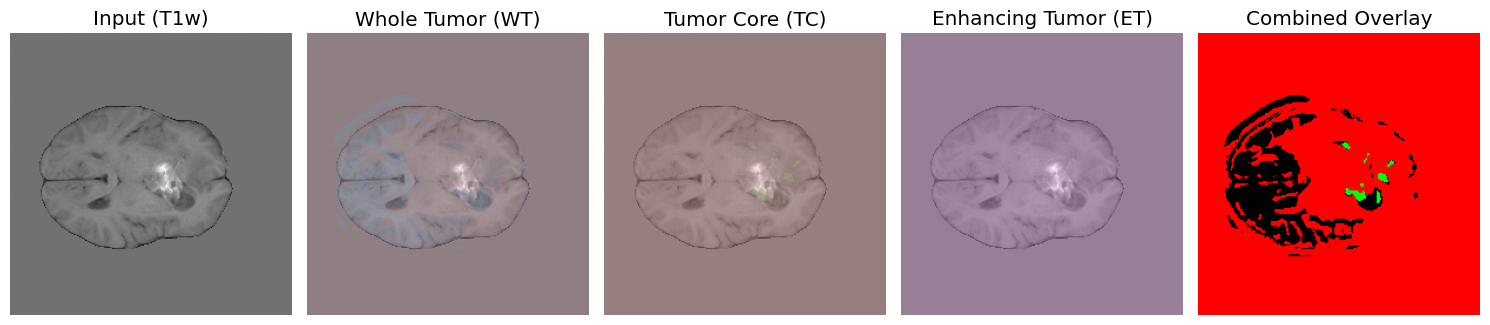

In [13]:
z_slice = inputs.shape[-1] //2

img_np = inputs[0, 0].cpu().numpy()
tc_np = tc_mask[0].cpu().numpy()
wt_np = wt_mask[0].cpu().numpy()
et_np = et_mask[0].cpu().numpy()

img_2d = img_np[:, :, z_slice]
wt_2d = wt_np[:, :, z_slice]
tc_2d = tc_np[:, :, z_slice]
et_2d = et_np[:, :, z_slice]

fix, ax = plt.subplots(1, 5, figsize=(15, 4))

# 1. Input image
ax[0].imshow(img_2d, cmap='gray')
ax[0].set_title('Input (T1w)')
ax[0].axis('off')

# 2. Whole Tumor (WT)
ax[1].imshow(img_2d, cmap='gray', alpha=0.8)
ax[1].imshow(wt_2d, cmap='coolwarm', alpha=0.1)
ax[1].set_title('Whole Tumor (WT)')
ax[1].axis('off')

# 3. Tumor Core (TC)
ax[2].imshow(img_2d, cmap='gray', alpha=0.8)
ax[2].imshow(tc_2d, cmap='autumn', alpha=0.1)
ax[2].set_title('Tumor Core (TC)')
ax[2].axis('off')

# 4. Enhancing Tumor (ET)
ax[3].imshow(img_2d, cmap='gray', alpha=0.8)
ax[3].imshow(et_2d, cmap='spring', alpha=0.1)
ax[3].set_title('Enhancing Tumor (ET)')
ax[3].axis('off')

# 5. Combined overlay (WT + TC + ET)
overlay = np.zeros((*img_2d.shape, 3))
overlay[wt_2d > 0] = [1, 0, 0]   # red = WT
overlay[tc_2d > 0] = [0, 1, 0]   # green = TC (overwrites red where overlaps)
overlay[et_2d > 0] = [1, 1, 0]   # yellow = ET

ax[4].imshow(img_2d, cmap='gray', alpha=0.8)
ax[4].imshow(overlay)
ax[4].set_title('Combined Overlay')
ax[4].axis('off')

plt.tight_layout()
plt.savefig('../report/figures/post_overlay.jpg', dpi=300, bbox_inches='tight')
plt.show()